logreg (chosen)  mean predicted 0.359   actual stress rate 0.343
lightgbm         mean predicted 0.298   actual stress rate 0.343
reference Brier (always predict the stress rate): 0.225


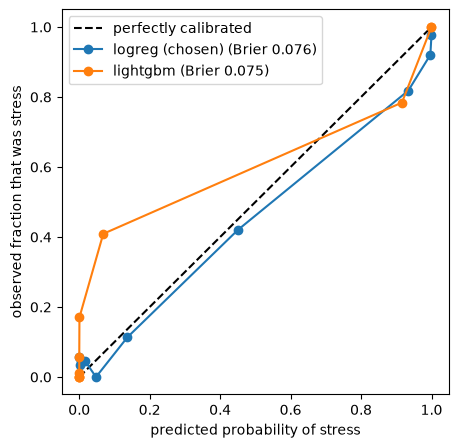

In [1]:

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from wearable_affect.tracking import load_run_predictions

runs = {
    "logreg (chosen)": "pers-5min-logreg-norm-fixed",
    "lightgbm": "pers-5min-lightgbm-norm-fixed",
}

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")

for label, run_name in runs.items():
    preds = load_run_predictions(run_name)
    observed, predicted = calibration_curve(preds["target"], preds["prob"], n_bins=10, strategy="quantile")
    brier = brier_score_loss(preds["target"], preds["prob"])
    ax.plot(predicted, observed, "o-", label=f"{label} (Brier {brier:.3f})")
    print(f"{label:16s} mean predicted {preds['prob'].mean():.3f}   actual stress rate {preds['target'].mean():.3f}")

rate = preds["target"].mean()
print(f"reference Brier (always predict the stress rate): {rate * (1 - rate):.3f}")

ax.set_xlabel("predicted probability of stress")
ax.set_ylabel("observed fraction that was stress")
ax.legend()
plt.show()